# 03_image_quality_control_and_exclusion_report — corrected Colab version

This notebook performs reproducible image-level quality control (QC) for the thermography dataset.


The notebook reads the master metadata generated from the folder structure and produces publication-ready QC reports. It does not silently remove images; it creates QC flags and an inclusion column for downstream notebooks.

## 1. Imports and paths

In [1]:
from pathlib import Path
import os, json, shutil, zipfile, hashlib, re, warnings
from datetime import datetime, timezone
import pandas as pd
import numpy as np


BASE_DIR = Path("/content")
PROJECT_NAME = "project_thermography_equine"
PROJECT_ROOT = BASE_DIR / PROJECT_NAME

DATA_ROOT = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_ROOT / "raw"
SPLIT_DATA_DIR = DATA_ROOT / "dataset_split"
METADATA_DIR = DATA_ROOT / "metadata"
ANNOTATIONS_DIR = DATA_ROOT / "annotations"

OUTPUT_ROOT = PROJECT_ROOT / "outputs"
CONFIG_DIR = OUTPUT_ROOT / "config"
REPORTS_DIR = OUTPUT_ROOT / "reports"
TABLES_DIR = OUTPUT_ROOT / "tables"
FIGURES_DIR = OUTPUT_ROOT / "figures"
MODELS_DIR = OUTPUT_ROOT / "models"
MODEL_SELECTION_DIR = OUTPUT_ROOT / "model_selection"

for p in [PROJECT_ROOT, DATA_ROOT, RAW_DATA_DIR, SPLIT_DATA_DIR, METADATA_DIR, ANNOTATIONS_DIR,
          OUTPUT_ROOT, CONFIG_DIR, REPORTS_DIR, TABLES_DIR, FIGURES_DIR, MODELS_DIR, MODEL_SELECTION_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Project paths initialized")
print("PROJECT_ROOT:", PROJECT_ROOT)
print("SPLIT_DATA_DIR:", SPLIT_DATA_DIR)
print("ANNOTATIONS_DIR:", ANNOTATIONS_DIR)
print("OUTPUT_ROOT:", OUTPUT_ROOT)

from PIL import Image, ImageStat, UnidentifiedImageError
try:
    import cv2
except Exception:
    cv2 = None
import matplotlib.pyplot as plt

Project paths initialized
PROJECT_ROOT: /content/project_thermography_equine
SPLIT_DATA_DIR: /content/project_thermography_equine/data/dataset_split
ANNOTATIONS_DIR: /content/project_thermography_equine/data/annotations
OUTPUT_ROOT: /content/project_thermography_equine/outputs


## 2. Load upstream metadata

In [2]:
required = [
    CONFIG_DIR / "analysis_config.json",
    CONFIG_DIR / "study_protocol.json",
]

missing = [str(p) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Run notebooks 00 and 01 first. Missing:\n" + "\n".join(missing)
    )

with open(CONFIG_DIR / "analysis_config.json", "r", encoding="utf-8") as f:
    analysis_config = json.load(f)

with open(CONFIG_DIR / "study_protocol.json", "r", encoding="utf-8") as f:
    study_protocol = json.load(f)

required_annotation_cols = [
    "has_hotspot_expert1",
    "has_hotspot_expert2",
    "has_hotspot_any_expert",
    "has_hotspot_both_experts",
    "expert_hotspot_disagreement",
    "healthy_with_expert_hotspot",
    "annotation_label_conflict",
    "annotation_clinical_note",
]


metadata_candidates = [
    CONFIG_DIR / "master_metadata_with_annotations.csv",
    METADATA_DIR / "master_metadata_with_annotations.csv",
    REPORTS_DIR / "master_metadata_with_annotations.csv",
    CONFIG_DIR / "master_metadata.csv",
]

metadata_path = next((p for p in metadata_candidates if p.exists()), None)
if metadata_path is None:
    raise FileNotFoundError(
        "Missing metadata. Run notebooks 01 and 02 first. Expected master_metadata_with_annotations.csv."
    )

master = pd.read_csv(metadata_path)
print("Using metadata:", metadata_path)
print("Rows:", len(master))

missing_annotation_cols = [c for c in required_annotation_cols if c not in master.columns]

if missing_annotation_cols:
    print("Metadata is missing annotation columns:", missing_annotation_cols)
    print("Attempting to repair from hotspot_consensus_by_image.csv generated by Notebook 02.")

    consensus_candidates = [
        CONFIG_DIR / "hotspot_consensus_by_image.csv",
        REPORTS_DIR / "hotspot_consensus_by_image.csv",
        BASE_DIR / "hotspot_consensus_by_image.csv",
    ] + sorted(BASE_DIR.glob("hotspot_consensus_by_image*.csv"), key=lambda p: p.stat().st_mtime, reverse=True)

    consensus_path = next((p for p in consensus_candidates if p.exists()), None)
    if consensus_path is None:
        raise FileNotFoundError(
            "Cannot repair metadata because hotspot_consensus_by_image.csv was not found. "
            "Run Notebook 02 with the corrected Scenario A logic first."
        )

    consensus = pd.read_csv(consensus_path)
    print("Using consensus:", consensus_path)

    consensus_required = ["split", "image_name"] + required_annotation_cols
    missing_consensus_cols = [c for c in consensus_required if c not in consensus.columns]
    if missing_consensus_cols:
        raise KeyError(
            "hotspot_consensus_by_image.csv is missing required columns: "
            + ", ".join(missing_consensus_cols)
        )


    stale_cols = [c for c in required_annotation_cols if c in master.columns]
    if stale_cols:
        master = master.drop(columns=stale_cols)

    master = master.merge(
        consensus[consensus_required].drop_duplicates(subset=["split", "image_name"]),
        on=["split", "image_name"],
        how="left",
        validate="one_to_one"
    )

    still_missing = [c for c in required_annotation_cols if c not in master.columns]
    if still_missing:
        raise KeyError(
            "Metadata repair failed. Still missing columns: " + ", ".join(still_missing)
        )

    missing_merged_rows = master[required_annotation_cols].isna().any(axis=1).sum()
    if missing_merged_rows:
        raise ValueError(
            f"Metadata repair failed: {missing_merged_rows} rows did not receive complete annotation flags. "
            "Check split/image_name consistency between metadata and consensus."
        )


    master.to_csv(CONFIG_DIR / "master_metadata_with_annotations.csv", index=False)
    master.to_csv(METADATA_DIR / "master_metadata_with_annotations.csv", index=False)
    master.to_csv(REPORTS_DIR / "master_metadata_with_annotations.csv", index=False)
    metadata_path = CONFIG_DIR / "master_metadata_with_annotations.csv"
    print("Repaired and saved:", metadata_path)


bool_annotation_cols = [c for c in required_annotation_cols if c != "annotation_clinical_note"]
for col in bool_annotation_cols:
    master[col] = master[col].astype(bool)
master["annotation_clinical_note"] = master["annotation_clinical_note"].astype(str)

n_healthy_hotspot = int(master["healthy_with_expert_hotspot"].sum())
if n_healthy_hotspot != 6:
    raise ValueError(
        "Unexpected number of clinically healthy images with expert-marked hotspot. "
        f"Expected 6 based on Notebook 02, observed {n_healthy_hotspot}."
    )

print("Healthy images with expert-marked hotspot:", n_healthy_hotspot)

display(
    master.groupby(
        ["split", "label_clinical", "healthy_with_expert_hotspot"]
    ).size().reset_index(name="n")
)

Using metadata: /content/project_thermography_equine/outputs/config/master_metadata_with_annotations.csv
Rows: 347
Healthy images with expert-marked hotspot: 6


,split,label_clinical,healthy_with_expert_hotspot,n
0,test,healthy,False,34
1,test,healthy,True,6
2,test,pathological,False,13
3,train,healthy,False,179
4,train,pathological,False,63
5,valid,healthy,False,38
6,valid,pathological,False,14


In [3]:


zip_candidates = sorted(
    list(BASE_DIR.glob("dataset_split*.zip")) +
    list(PROJECT_ROOT.glob("dataset_split*.zip")) +
    list(RAW_DATA_DIR.glob("dataset_split*.zip")),
    key=lambda p: p.stat().st_mtime,
    reverse=True
)

print("ZIP candidates:")
for z in zip_candidates:
    print(" -", z)

SPLIT_DATA_DIR.mkdir(parents=True, exist_ok=True)

image_exts = [".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"]

def count_images(root):
    files = []
    for ext in image_exts:
        files.extend(root.rglob(f"*{ext}"))
        files.extend(root.rglob(f"*{ext.upper()}"))
    return files

existing_images = count_images(SPLIT_DATA_DIR)
print("Existing images before extraction:", len(existing_images))

if len(existing_images) == 0:
    if not zip_candidates:
        raise FileNotFoundError(
            "No dataset_split ZIP found. Upload dataset_split ZIP to /content or RAW_DATA_DIR."
        )

    zip_path = zip_candidates[0]
    print("Extracting:", zip_path)


    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(DATA_ROOT)

    print("Extraction finished.")


nested_dataset_split = SPLIT_DATA_DIR / "dataset_split"
if nested_dataset_split.exists():
    print("Nested dataset_split detected. Moving contents up one level.")
    for item in nested_dataset_split.iterdir():
        target = SPLIT_DATA_DIR / item.name
        if not target.exists():
            shutil.move(str(item), str(target))
    try:
        nested_dataset_split.rmdir()
    except OSError:
        pass


for split_name in ["train", "valid", "test"]:
    source = DATA_ROOT / split_name
    target = SPLIT_DATA_DIR / split_name
    if source.exists() and not target.exists():
        print(f"Moving extracted {source} -> {target}")
        shutil.move(str(source), str(target))

existing_images = count_images(SPLIT_DATA_DIR)
print("Existing images after extraction:", len(existing_images))

if len(existing_images) == 0:
    raise FileNotFoundError(
        f"No images found in {SPLIT_DATA_DIR}. Check ZIP structure."
    )

ZIP candidates:
 - /content/dataset_split-20260605T090743Z-3-001.zip
Existing images before extraction: 0
Extracting: /content/dataset_split-20260605T090743Z-3-001.zip
Extraction finished.
Existing images after extraction: 347


## 3. Validate required columns

In [4]:
required_columns = [
    "horse_id", "image_name", "split", "folder_label", "label_clinical",
    "label_binary", "image_path", "relative_image_path"
]
missing_cols = [c for c in required_columns if c not in master.columns]
if missing_cols:
    raise KeyError("Metadata is missing required columns:\n" + "\n".join(missing_cols))


def resolve_image_path(row):
    raw_image_path = Path(str(row["image_path"]))
    rel = Path(str(row["relative_image_path"]))

    candidates = []

    if raw_image_path.is_absolute():
        candidates.append(raw_image_path)
    else:
        candidates.extend([
            PROJECT_ROOT / raw_image_path,
            DATA_ROOT / raw_image_path,
            SPLIT_DATA_DIR / raw_image_path,
        ])

    candidates.extend([
        SPLIT_DATA_DIR / rel,
        DATA_ROOT / "dataset_split" / rel,
        DATA_ROOT / rel,
        PROJECT_ROOT / rel,
        BASE_DIR / rel,
    ])


    candidates.append(SPLIT_DATA_DIR / str(row["split"]) / str(row["folder_label"]) / str(row["image_name"]))

    seen = set()
    for candidate in candidates:
        candidate = Path(candidate)
        if candidate in seen:
            continue
        seen.add(candidate)
        if candidate.exists():
            return candidate


    return SPLIT_DATA_DIR / rel

master["resolved_image_path"] = master.apply(resolve_image_path, axis=1).astype(str)
missing_images = master[~master["resolved_image_path"].apply(lambda x: Path(x).exists())].copy()
print("Missing images:", len(missing_images))
if len(missing_images):
    display(missing_images[["split", "label_clinical", "image_name", "relative_image_path", "resolved_image_path"]].head(20))
    raise FileNotFoundError(
        f"{len(missing_images)} images are missing after ZIP extraction/path resolution. "
        "Fix image paths before running QC."
    )
else:
    print("All image paths resolved successfully.")

Missing images: 0
All image paths resolved successfully.


## 4. QC protocol

In [5]:
qc_protocol = {
    "qc_timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "automated_checks": [
        "file exists",
        "image can be opened by PIL",
        "width and height are positive",
        "image dimensions are consistent with metadata and annotation expectations",
        "file size is non-zero",
        "basic brightness and contrast metrics",
        "optional Laplacian sharpness metric if OpenCV is available",
    ],
    "default_exclusion_rules": {
        "missing_file": True,
        "unreadable_image": True,
        "non_positive_dimensions": True,
        "zero_file_size": True,
    },
    "manual_qc_policy": "Manual exclusions, if any, should be added in manual_qc_decision after visual review. This notebook does not silently remove borderline images based on automated brightness/sharpness alone."
}
with open(CONFIG_DIR / "qc_protocol.json", "w", encoding="utf-8") as f:
    json.dump(qc_protocol, f, indent=2, ensure_ascii=False)
with open(REPORTS_DIR / "qc_protocol.json", "w", encoding="utf-8") as f:
    json.dump(qc_protocol, f, indent=2, ensure_ascii=False)
print(json.dumps(qc_protocol, indent=2, ensure_ascii=False))

{
  "qc_timestamp_utc": "2026-06-06T15:30:16.108374+00:00",
  "automated_checks": [
    "file exists",
    "image can be opened by PIL",
    "width and height are positive",
    "image dimensions are consistent with metadata and annotation expectations",
    "file size is non-zero",
    "basic brightness and contrast metrics",
    "optional Laplacian sharpness metric if OpenCV is available"
  ],
  "default_exclusion_rules": {
    "missing_file": true,
    "unreadable_image": true,
    "non_positive_dimensions": true,
    "zero_file_size": true
  },
  "manual_qc_policy": "Manual exclusions, if any, should be added in manual_qc_decision after visual review. This notebook does not silently remove borderline images based on automated brightness/sharpness alone."
}


## 5. Compute image QC metrics

In [6]:
def image_metrics(path):
    path = Path(path)
    row = {
        "file_exists": path.exists(),
        "readable_image": False,
        "qc_error": "",
        "width": np.nan,
        "height": np.nan,
        "mode": "",
        "file_size_bytes_qc": np.nan,
        "mean_intensity": np.nan,
        "std_intensity": np.nan,
        "min_intensity": np.nan,
        "max_intensity": np.nan,
        "laplacian_variance": np.nan,
    }
    if not path.exists():
        row["qc_error"] = "missing_file"
        return row
    row["file_size_bytes_qc"] = path.stat().st_size
    if path.stat().st_size <= 0:
        row["qc_error"] = "zero_file_size"
        return row
    try:
        with Image.open(path) as img:
            img.load()
            row["readable_image"] = True
            row["width"], row["height"] = img.size
            row["mode"] = img.mode
            gray = img.convert("L")
            arr = np.asarray(gray, dtype=np.float32)
            row["mean_intensity"] = float(np.mean(arr))
            row["std_intensity"] = float(np.std(arr))
            row["min_intensity"] = float(np.min(arr))
            row["max_intensity"] = float(np.max(arr))
            if cv2 is not None:
                row["laplacian_variance"] = float(cv2.Laplacian(arr.astype(np.uint8), cv2.CV_64F).var())
    except (UnidentifiedImageError, OSError, ValueError) as e:
        row["qc_error"] = f"unreadable_image: {type(e).__name__}: {e}"
    return row

metric_rows = []
for _, r in master.iterrows():
    m = image_metrics(r["resolved_image_path"])
    metric_rows.append({**r.to_dict(), **m})

qc = pd.DataFrame(metric_rows)
qc["non_positive_dimensions"] = (qc["width"].fillna(0) <= 0) | (qc["height"].fillna(0) <= 0)
qc["zero_file_size"] = qc["file_size_bytes_qc"].fillna(0) <= 0
qc["dimension_mismatch_metadata"] = False
if "file_size_bytes" in qc.columns:
    qc["file_size_mismatch_metadata"] = qc["file_size_bytes"].fillna(-1).astype(float) != qc["file_size_bytes_qc"].fillna(-2).astype(float)
else:
    qc["file_size_mismatch_metadata"] = False


qc["automated_exclusion"] = (
    (~qc["file_exists"].astype(bool)) |
    (~qc["readable_image"].astype(bool)) |
    qc["non_positive_dimensions"].astype(bool) |
    qc["zero_file_size"].astype(bool)
)
qc["manual_qc_decision"] = "include"
qc["manual_qc_reason"] = ""
qc["included_after_qc"] = ~qc["automated_exclusion"]

print("QC rows:", len(qc))
print("Automated exclusions:", int(qc["automated_exclusion"].sum()))
display(qc[["split", "label_clinical", "image_name", "file_exists", "readable_image", "width", "height", "automated_exclusion", "qc_error"]].head())

QC rows: 347
Automated exclusions: 0


,split,label_clinical,image_name,file_exists,readable_image,width,height,automated_exclusion,qc_error
0,test,healthy,0A0F5.jpg,True,True,492,331,False,
1,test,healthy,1CGFM.jpg,True,True,492,331,False,
2,test,healthy,1RDFC.jpg,True,True,492,331,False,
3,test,healthy,31W0A.jpg,True,True,492,331,False,
4,test,healthy,6BGWZ.jpg,True,True,492,331,False,


## 6. QC summaries

In [7]:
qc_summary_by_split = qc.groupby(["split", "label_clinical", "label_binary"]).agg(
    n_images=("image_name", "count"),
    n_missing=("file_exists", lambda s: int((~s.astype(bool)).sum())),
    n_unreadable=("readable_image", lambda s: int((~s.astype(bool)).sum())),
    n_automated_excluded=("automated_exclusion", "sum"),
    mean_width=("width", "mean"),
    mean_height=("height", "mean"),
    median_file_size_bytes=("file_size_bytes_qc", "median"),
    median_laplacian_variance=("laplacian_variance", "median"),
    median_intensity_std=("std_intensity", "median"),
).reset_index()

qc_summary_overall = pd.DataFrame([{
    "n_images": len(qc),
    "n_missing": int((~qc["file_exists"].astype(bool)).sum()),
    "n_unreadable": int((~qc["readable_image"].astype(bool)).sum()),
    "n_automated_excluded": int(qc["automated_exclusion"].sum()),
    "n_included_after_qc": int(qc["included_after_qc"].sum()),
    "median_width": float(qc["width"].median()),
    "median_height": float(qc["height"].median()),
    "median_file_size_bytes": float(qc["file_size_bytes_qc"].median()),
    "median_laplacian_variance": float(qc["laplacian_variance"].median()) if qc["laplacian_variance"].notna().any() else np.nan,
}])

display(qc_summary_by_split)
display(qc_summary_overall)

# Potential manual review candidates: technically readable but unusually low contrast/sharpness.
review = qc[qc["included_after_qc"]].copy()
if len(review):
    low_contrast_threshold = review["std_intensity"].quantile(0.02)
    review["low_contrast_flag"] = review["std_intensity"] <= low_contrast_threshold
    if review["laplacian_variance"].notna().any():
        low_sharpness_threshold = review["laplacian_variance"].quantile(0.02)
        review["low_sharpness_flag"] = review["laplacian_variance"] <= low_sharpness_threshold
    else:
        low_sharpness_threshold = np.nan
        review["low_sharpness_flag"] = False
    manual_review_candidates = review[review["low_contrast_flag"] | review["low_sharpness_flag"]].copy()
else:
    low_contrast_threshold = np.nan
    low_sharpness_threshold = np.nan
    manual_review_candidates = review.copy()

print("Suggested manual review candidates:", len(manual_review_candidates))
display(manual_review_candidates[["split", "label_clinical", "image_name", "std_intensity", "laplacian_variance", "relative_image_path"]].head(30))

,split,label_clinical,label_binary,n_images,n_missing,n_unreadable,n_automated_excluded,mean_width,mean_height,median_file_size_bytes,median_laplacian_variance,median_intensity_std
0,test,healthy,0,40,0,0,0,492.0,331.0,24034.5,130.600691,55.157904
1,test,pathological,1,13,0,0,0,492.0,331.0,24992.0,185.796738,57.365185
2,train,healthy,0,179,0,0,0,492.0,331.0,24202.0,128.441671,57.579754
3,train,pathological,1,63,0,0,0,492.0,331.0,24748.0,160.573791,57.445107
4,valid,healthy,0,38,0,0,0,492.0,331.0,25653.5,137.026287,56.588682
5,valid,pathological,1,14,0,0,0,492.0,331.0,20567.5,134.030134,58.180515


,n_images,n_missing,n_unreadable,n_automated_excluded,n_included_after_qc,median_width,median_height,median_file_size_bytes,median_laplacian_variance
0,347,0,0,0,347,492.0,331.0,24416.0,139.702858


Suggested manual review candidates: 11


,split,label_clinical,image_name,std_intensity,laplacian_variance,relative_image_path
22,test,healthy,N2OOM.jpg,21.360853,24.299466,test/healthy/N2OOM.jpg
86,train,healthy,6A2TX.jpg,26.952589,21.096486,train/healthy/6A2TX.jpg
103,train,healthy,91FFA.jpg,25.994211,46.701531,train/healthy/91FFA.jpg
143,train,healthy,HTUEZ.jpg,24.328838,19.333847,train/healthy/HTUEZ.jpg
172,train,healthy,OFJKM.jpg,23.178724,16.901415,train/healthy/OFJKM.jpg
184,train,healthy,Q4SVL.jpg,29.852739,16.919125,train/healthy/Q4SVL.jpg
189,train,healthy,QT8N9.jpg,29.857552,19.918834,train/healthy/QT8N9.jpg
190,train,healthy,QVNAK.jpg,26.852577,38.835149,train/healthy/QVNAK.jpg
206,train,healthy,UIE1N.jpg,35.062206,14.939059,train/healthy/UIE1N.jpg
209,train,healthy,VDBER.jpg,27.535496,16.311227,train/healthy/VDBER.jpg


In [8]:

expected_healthy_hotspot = int(master["healthy_with_expert_hotspot"].sum())
observed_qc_healthy_hotspot = int(qc["healthy_with_expert_hotspot"].sum()) if "healthy_with_expert_hotspot" in qc.columns else -1

if expected_healthy_hotspot != 6:
    raise ValueError(f"Expected 6 healthy_with_expert_hotspot cases in master, observed {expected_healthy_hotspot}.")
if observed_qc_healthy_hotspot != expected_healthy_hotspot:
    raise ValueError(
        "healthy_with_expert_hotspot count changed during QC metric generation. "
        f"Expected {expected_healthy_hotspot}, observed {observed_qc_healthy_hotspot}."
    )

print("QC rows:", len(qc))
print("Included after QC:", int(qc["included_after_qc"].sum()), "/", len(qc))
print("Healthy images with expert-marked hotspot retained in QC table:", observed_qc_healthy_hotspot)

QC rows: 347
Included after QC: 347 / 347
Healthy images with expert-marked hotspot retained in QC table: 6


## 7. Save QC outputs

In [9]:
qc.to_csv(CONFIG_DIR / "image_qc_metrics.csv", index=False)
qc.to_csv(REPORTS_DIR / "image_qc_metrics.csv", index=False)

qc_summary_by_split.to_csv(CONFIG_DIR / "image_qc_summary_by_split.csv", index=False)
qc_summary_by_split.to_csv(REPORTS_DIR / "image_qc_summary_by_split.csv", index=False)

qc_summary_overall.to_csv(CONFIG_DIR / "image_qc_summary_overall.csv", index=False)
qc_summary_overall.to_csv(REPORTS_DIR / "image_qc_summary_overall.csv", index=False)

manual_review_candidates.to_csv(REPORTS_DIR / "image_qc_manual_review_candidates.csv", index=False)
manual_review_candidates.to_csv(CONFIG_DIR / "image_qc_manual_review_candidates.csv", index=False)


master_qc_cols = [
    "split", "image_name", "file_exists", "readable_image", "width", "height",
    "mean_intensity", "std_intensity", "laplacian_variance", "automated_exclusion",
    "manual_qc_decision", "manual_qc_reason", "included_after_qc"
]

missing_qc_cols = [c for c in master_qc_cols if c not in qc.columns]
if missing_qc_cols:
    raise KeyError("QC table is missing required columns: " + ", ".join(missing_qc_cols))

master_with_qc = master.merge(
    qc[master_qc_cols],
    on=["split", "image_name"],
    how="left",
    validate="one_to_one"
)

missing_qc_rows = int(master_with_qc["included_after_qc"].isna().sum())
if missing_qc_rows > 0:
    raise ValueError(
        f"{missing_qc_rows} metadata rows did not receive QC results. Check merge keys: split and image_name."
    )

master_with_qc["included_in_final_analysis"] = master_with_qc["included_after_qc"].astype(bool)

expected_healthy_hotspot = int(master["healthy_with_expert_hotspot"].sum())
observed_healthy_hotspot = int(master_with_qc["healthy_with_expert_hotspot"].sum())
if observed_healthy_hotspot != expected_healthy_hotspot:
    raise ValueError(
        "healthy_with_expert_hotspot count changed during QC merge. "
        f"Expected {expected_healthy_hotspot}, observed {observed_healthy_hotspot}."
    )

master_with_qc.to_csv(CONFIG_DIR / "master_metadata_qc.csv", index=False)
master_with_qc.to_csv(METADATA_DIR / "master_metadata_qc.csv", index=False)
master_with_qc.to_csv(REPORTS_DIR / "master_metadata_qc.csv", index=False)


qc_summary_by_split.to_csv(TABLES_DIR / "table_image_qc_summary_by_split.csv", index=False)
qc_summary_overall.to_csv(TABLES_DIR / "table_image_qc_summary_overall.csv", index=False)

print("Saved QC outputs.")
print("Included after QC:", int(master_with_qc["included_in_final_analysis"].sum()), "/", len(master_with_qc))
print("Healthy images with expert-marked hotspot retained:", observed_healthy_hotspot)

Saved QC outputs.
Included after QC: 347 / 347
Healthy images with expert-marked hotspot retained: 6


## 8. Optional QC figure

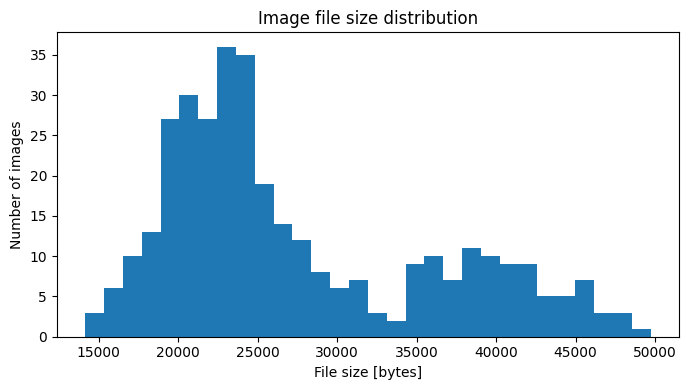

Saved: /content/project_thermography_equine/outputs/figures/image_qc_file_size_distribution.png


In [10]:

try:
    plt.figure(figsize=(7, 4))
    qc["file_size_bytes_qc"].dropna().plot(kind="hist", bins=30)
    plt.xlabel("File size [bytes]")
    plt.ylabel("Number of images")
    plt.title("Image file size distribution")
    plt.tight_layout()
    fig_path = FIGURES_DIR / "image_qc_file_size_distribution.png"
    plt.savefig(fig_path, dpi=300)
    plt.show()
    print("Saved:", fig_path)
except Exception as e:
    print("Figure generation skipped:", e)

## 9. Methods text seed

In [11]:
overall = qc_summary_overall.iloc[0]
qc_methods_text = (
    f"Automated image-level quality control was applied to {int(overall['n_images'])} thermographic images. "
    f"The QC procedure verified file availability, readability, non-zero file size and positive image dimensions. "
    f"Objective technical failures were marked for exclusion; borderline brightness, contrast or sharpness findings were retained for manual review rather than being silently excluded. "
    f"After automated QC, {int(overall['n_included_after_qc'])} images remained eligible for downstream analysis."
)
(CONFIG_DIR / "methods_image_qc_text.txt").write_text(qc_methods_text, encoding="utf-8")
(REPORTS_DIR / "methods_image_qc_text.txt").write_text(qc_methods_text, encoding="utf-8")
print(qc_methods_text)

Automated image-level quality control was applied to 347 thermographic images. The QC procedure verified file availability, readability, non-zero file size and positive image dimensions. Objective technical failures were marked for exclusion; borderline brightness, contrast or sharpness findings were retained for manual review rather than being silently excluded. After automated QC, 347 images remained eligible for downstream analysis.
